---
title: "Welcome to the Documentation"
author: "Miguel R."
date: today
categories: [logistic regression, classification]
description: "This is a documentation."
---

# What is Logistic Regression?

- Logistic Regression is supervised Machine Learning Algorithm used for classification tasks.
- Is suitable for binary (yes/no) and multi-class classification problems, but often you see it on binary.
-

# Data
for this, let's say we want to predict a common problem

In [3]:
import numpy as np

X = np.array([35, 42, 55, 61, 68, 72, 78, 85, 91, 96])
y_true = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])




# Data

Our data is simple, in one side we have the relative humidity in % as de independent variable ($X$),
where in this dataset the separation of a rainy day or not, its between 61% and 68%

In [57]:
import plotly.graph_objects as go
import numpy as np


def plot_class(X, y_true, line=None, title=None):
    fig = go.Figure()
    fig.add_trace(
        go.Scatter(x=X[y_true == 1],
                   y=y_true[y_true == 1],
                   name='Rain (1)',
                   mode='markers',
                   marker=dict(color='blue'
                               )))
    fig.add_trace(
        go.Scatter(x=X[y_true == 0],
                   y=y_true[y_true == 0],
                   name='No Rain (0)',
                   mode='markers',
                   marker=dict(color='green'
                               )))
    if line:
        steps = np.linspace(0, 100, 50)
        fig.add_trace(go.Scatter(
            x=[line, line],
            y=[0, 1],
            mode='lines',
            line=dict(color='red', width=3, dash='dash'),
            name='Threshold'
        ))
        fig.add_trace(go.Scatter(x=[line - 2], y=[0.5], text=["Not Rain"],
                                 mode='text', textposition="middle left", name='Left Label',
                                 textfont=dict(color="green", size=14)))

        fig.add_trace(go.Scatter(x=[line + 2], y=[0.5], text=["Rain"],
                                 mode='text', textposition="middle right", name='Right Label',
                                 textfont=dict(color="blue", size=14)))
        frames = []
        for step in steps:
            frames.append(go.Frame(
                data=[
                    go.Scatter(x=X[y_true == 1], y=y_true[y_true == 1]),
                    go.Scatter(x=X[y_true == 0], y=y_true[y_true == 0]),
                    go.Scatter(x=[step, step], y=[-0.1, 1.1]),
                    go.Scatter(x=[step - 2]),
                    go.Scatter(x=[step + 2])
                ],
                name=str(int(round(step, 0)))
            ))
        fig.frames = frames
        sliders = [{
            'active': int(line/2),
            'currentvalue': {"prefix": "Rain division at ", "suffix": "% of relativity humidity."},
            'pad': {"t": 50},
            'steps': [
                {
                    'args': [
                        [f.name],
                        {'frame': {'duration': 0, 'redraw': False}, 'mode': 'immediate'}
                    ],
                    'label': f.name,
                    'method': 'animate'
                } for f in frames
            ]
        }]
        fig.update_layout(
            sliders=sliders,
            xaxis=dict(range=[0, 105]),
            yaxis=dict(range=[-0.1, 1.1]),
            title=title
        )

    return fig


plot_class(X=X, y_true=y_true, line=59, title='Naive rainy data points').show()

in our data we have a solid separation between a rainy/normal day,
pretty much we could draw a vertical line in the middle between 61 and 68,
and we have a perfect classification model, if the relativty humidity is **greater 64.5% it's going to rain**.
let's have a more real world example where our data is not that clean.

In [45]:
more_rain_points_X = [55, 58, 63, 66, 69, 80, 85, 90, 92, 95, 96, 97, 99]
more_rain_points_y = [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
more_normal_points_X = [10, 13, 15, 18, 20, 30, 40, 50, 52, 54, 55, 60, 61]
more_normal_points_y = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

In [55]:
X = np.concatenate((more_rain_points_X, X, more_normal_points_X))
y_true = np.concatenate((more_rain_points_y, y_true, more_normal_points_y))
plt_sigmoid = plot_class(X, y_true, line=58,title='We cannot longer draw a simple line to separate rainy days.').show()

shape sigmoid (36,)
[0.         0.02857143 0.05714286 0.08571429 0.11428571 0.14285714
 0.17142857 0.2        0.22857143 0.25714286 0.28571429 0.31428571
 0.34285714 0.37142857 0.4        0.42857143 0.45714286 0.48571429
 0.51428571 0.54285714 0.57142857 0.6        0.62857143 0.65714286
 0.68571429 0.71428571 0.74285714 0.77142857 0.8        0.82857143
 0.85714286 0.88571429 0.91428571 0.94285714 0.97142857 1.        ]
shape x (36,)
None


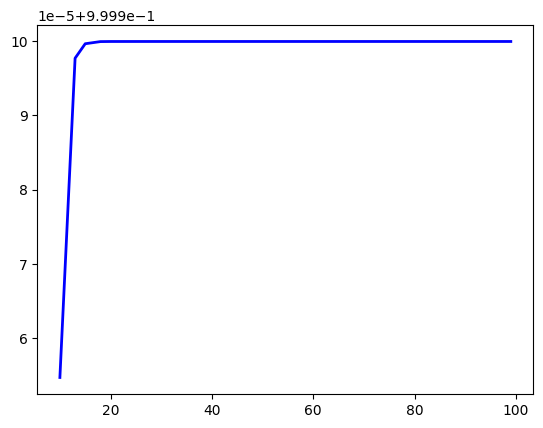

In [10]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


naive_sigmoid_x = np.linspace(0, 1, 36)
print('shape sigmoid', naive_sigmoid_x.shape)
print(naive_sigmoid_x)
print('shape x', X.shape)
print(X.sort())
naive_sigmoid = sigmoid(X)
plt_sigmoid.plot(X, naive_sigmoid, color='blue', linewidth=2)
plt_sigmoid.show()

#

In [6]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))
